
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

In [2]:
df = pd.read_csv('/Users/abhigoyal/Documents/Acadss/Data Science/Projects/Flight-Delay-Prediction/data/flight_data_2018_2024.csv')
print(df.shape)
df.sample(3)

(582425, 120)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
382565,2024,1,1,2,2,2024-01-02,UA,UA,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
165456,2024,1,1,25,4,2024-01-25,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
5796,2024,1,1,3,3,2024-01-03,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


---
## 2. Data Understanding

We begin with a structured audit of columns, types, and basic statistics.


In [ ]:
print(f"Columns : {df.shape[1]}")
print(f"Rows    : {df.shape[0]}")
print()
df.info(verbose=True, show_counts=True)


Columns : 120
Rows    : 582425

<class 'pandas.DataFrame'>
RangeIndex: 582425 entries, 0 to 582424
Data columns (total 120 columns):
 #    Column                                              Non-Null Count   Dtype  
---   ------                                              --------------   -----  
 0    Year                                                582425 non-null  int64  
 1    Quarter                                             582425 non-null  int64  
 2    Month                                               582425 non-null  int64  
 3    DayofMonth                                          582425 non-null  int64  
 4    DayOfWeek                                           582425 non-null  int64  
 5    FlightDate                                          582425 non-null  str    
 6    Marketing_Airline_Network                           582425 non-null  str    
 7    Operated_or_Branded_Code_Share_Partners             582425 non-null  str    
 8    DOT_ID_Marketing_Airline       

In [3]:
# descriptive statistics for important numeric columns
key_cols = ['DepDelay', 'ArrDelay', 'Distance', 'TaxiOut', 'TaxiIn',
            'AirTime', 'CRSElapsedTime', 'CarrierDelay',
            'WeatherDelay', 'NASDelay', 'LateAircraftDelay']
df[key_cols].describe().round(2)

,DepDelay,ArrDelay,Distance,TaxiOut,TaxiIn,AirTime,CRSElapsedTime,CarrierDelay,WeatherDelay,NASDelay,LateAircraftDelay
count,560955.00,558715.00,582425.00,560515.00,560093.00,558715.00,582425.00,134575.00,134575.00,134575.00,134575.00
mean,15.97,10.66,809.34,18.98,8.28,113.29,146.07,24.64,8.02,13.52,30.58
std,66.06,68.65,588.76,11.51,6.95,70.21,72.41,80.81,52.31,30.15,68.25
min,-56.00,-90.00,31.00,1.00,1.00,7.00,26.00,0.00,0.00,0.00,0.00
25%,-6.00,-16.00,377.00,12.00,4.00,62.00,93.00,0.00,0.00,0.00,0.00
50%,-2.00,-5.00,661.00,16.00,6.00,96.00,130.00,2.00,0.00,1.00,1.00
75%,12.00,13.00,1050.00,22.00,10.00,144.00,177.00,21.00,0.00,18.00,35.00
max,3125.00,3136.00,5095.00,213.00,444.00,1338.00,690.00,2972.00,1804.00,1431.00,1741.00


In [4]:
# missing value audit
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Missing Count': missing, 'Missing %': pct})

,Missing Count,Missing %
Unnamed: 119,582425,100.0
Div5Airport,582425,100.0
Div4AirportID,582425,100.0
Div4AirportSeqID,582425,100.0
Div4WheelsOn,582425,100.0
...,...,...
DepDel15,21470,3.7
DepDelayMinutes,21470,3.7
DepDelay,21470,3.7
DepTime,21396,3.7


- CarrierDelay, WeatherDelay, NASDelay, SecurityDelay, LateAircraftDelay are 77% null — only populated for delayed flights.
- They are valuable for EDA but can't be used as model features (target leakage).
- ArrDelay / DepDelay are ~4% null — cancelled or diverted flights.
- Diversion kind of columns are >99% null and will be dropped.


---
## 3. Data Cleaning


In [5]:
df['FlightDate'] = pd.to_datetime(df['FlightDate'])
df['Year']       = df['FlightDate'].dt.year
df['Month']      = df['FlightDate'].dt.month
df['DayofMonth'] = df['FlightDate'].dt.day
df['DayOfWeek']  = df['FlightDate'].dt.dayofweek   # 0=Mon ... 6=Sun

# drop near-empty diverted-leg columns (>95% na valuews)
div_cols = [c for c in df.columns if c.startswith('Div') and c != 'Diverted']
df.drop(columns=div_cols + ['Unnamed: 119'], errors='ignore', inplace=True)

# filter to non-cancelled flights
df_model = df[df['Cancelled'] == 0].copy()
df_model.dropna(subset=['ArrDelay', 'DepDelay'], inplace=True)

# ceate binary target: Arrived >15 min late
df_model['ArrDel15'] = (df_model['ArrDelay'] > 15).astype(int)

print(f"Rows after cleaning : {len(df_model):,}")
print(f"Delayed (>15 min)   : {df_model['ArrDel15'].sum():,}  "f"({df_model['ArrDel15'].mean()*100:.1f}%)")
print(f"On-time             : {(df_model['ArrDel15']==0).sum():,}  "f"({(1-df_model['ArrDel15'].mean())*100:.1f}%)")


Rows after cleaning : 558,715
Delayed (>15 min)   : 130,480  (23.4%)
On-time             : 428,235  (76.6%)


In [6]:
# leakage check: columns only known after the departure of flight 
leakage_cols = ['ArrDelay', 'ArrDelayMinutes', 'ArrivalDelayGroups',
                'DepDelay', 'DepDelayMinutes', 'DepartureDelayGroups',
                'CarrierDelay', 'WeatherDelay', 'NASDelay',
                'SecurityDelay', 'LateAircraftDelay',
                'DepDel15', 'ArrTime', 'WheelsOff', 'WheelsOn',
                'ActualElapsedTime', 'AirTime', 'TaxiIn',
                'FirstDepTime', 'TotalAddGTime', 'LongestAddGTime']

print("total leakage columns :", len(leakage_cols))
# these will be excluded from the feature matrix X


total leakage columns : 21


---
## 4. Feature Engineering

We create domain-informed features using information
available at booking time — zero data leakage.


In [7]:
df_model['DepHour']   = (df_model['CRSDepTime'] // 100).clip(0, 23)
df_model['DepMinute'] = df_model['CRSDepTime'] % 100

# Weekend flag (Sat=5, Sun=6 )
df_model['IsWeekend'] = df_model['DayOfWeek'].isin([5, 6]).astype(int)

# peak-hour flag: 07-09 morning peak and 16-19 evening peak
df_model['IsPeakHour'] = df_model['DepHour'].isin(
    list(range(7, 10)) + list(range(16, 20))
).astype(int)

# season (meteorological)
df_model['Season'] = df_model['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
     3: 'Spring', 4: 'Spring', 5: 'Spring',
     6: 'Summer', 7: 'Summer', 8: 'Summer',
     9: 'Fall',  10: 'Fall',  11: 'Fall'
})

# holiday-adjacent flag
holiday_windows = (
    ((df_model['Month'] == 12) & (df_model['DayofMonth'] >= 15)) |
    ((df_model['Month'] ==  1) & (df_model['DayofMonth'] <=  7)) |
    ((df_model['Month'] ==  6) & (df_model['DayofMonth'] >= 15)) |
    ((df_model['Month'] ==  7) & (df_model['DayofMonth'] <=  7)) |
    ((df_model['Month'] == 11) & (df_model['DayofMonth'] >= 20))
)
df_model['HolidayWindow'] = holiday_windows.astype(int)

In [8]:
df_model['Route'] = df_model['Origin'] + '_' + df_model['Dest']

bins   = [0, 300, 600, 1000, 1500, 9999]
labels_db = ['Short', 'Medium', 'Long', 'X-Long', 'Ultra']
df_model['DistanceBucket'] = pd.cut(df_model['Distance'],
                                    bins=bins, labels=labels_db)

In [9]:
# airport congestion (origin flight count per day) 
daily_origin_volume = (df_model
                       .groupby(['Origin', 'FlightDate'])['ArrDel15']
                       .count()
                       .reset_index(name='OriginDailyFlights'))

df_model = df_model.merge(daily_origin_volume,
                          on=['Origin', 'FlightDate'], how='left')

In [10]:
# Airline Historical Performance
airline_hist = (df_model.groupby('Marketing_Airline_Network')['ArrDel15']
                .mean()
                .reset_index(name='AirlineHistDelayRate'))

df_model = df_model.merge(airline_hist,
                          on='Marketing_Airline_Network', how='left')

# origin airport historical delay rate
origin_hist = (df_model.groupby('Origin')['ArrDel15']
               .mean()
               .reset_index(name='OriginHistDelayRate'))

df_model = df_model.merge(origin_hist, on='Origin', how='left')

In [11]:
# Scheduled TaxiOut as congestion proxy
avg_taxiout = (df_model.groupby('Origin')['TaxiOut']
                   .mean()
                   .reset_index(name='AvgOriginTaxiOut'))
df_model = df_model.merge(avg_taxiout, on='Origin', how='left')

In [12]:
# Circular encoding for cyclic features 
for col, period in [('DepHour', 24), ('Month', 12), ('DayOfWeek', 7)]:
    df_model[f'{col}_sin'] = np.sin(2 * np.pi * df_model[col] / period)
    df_model[f'{col}_cos'] = np.cos(2 * np.pi * df_model[col] / period)

In [13]:
# feature summary
engineered = ['IsWeekend', 'IsPeakHour', 'Season', 'HolidayWindow',
              'Route', 'DistanceBucket',
              'OriginDailyFlights', 'AirlineHistDelayRate',
              'OriginHistDelayRate', 'AvgOriginTaxiOut',
              'DepHour_sin', 'DepHour_cos',
              'Month_sin', 'Month_cos',
              'DayOfWeek_sin', 'DayOfWeek_cos']

print(f"Total engineered features : {len(engineered)}")
df_model[engineered].head(3)


Total engineered features : 16


,IsWeekend,IsPeakHour,Season,HolidayWindow,Route,DistanceBucket,OriginDailyFlights,AirlineHistDelayRate,OriginHistDelayRate,AvgOriginTaxiOut,DepHour_sin,DepHour_cos,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
0,1,1,Winter,0,MHT_EWR,Short,17,0.21392,0.212632,17.722105,-0.965926,-0.258819,0.5,0.866025,-0.781831,0.62349
1,1,1,Winter,0,IAD_EWR,Short,156,0.21392,0.230755,23.113864,0.866025,-0.500000,0.5,0.866025,-0.781831,0.62349
2,1,0,Winter,0,EWR_MHT,Short,328,0.21392,0.190097,22.519281,-0.707107,-0.707107,0.5,0.866025,-0.781831,0.62349


In [ ]:
df

NameError: name 'X' is not defined

---
## 5. Modelling

### 5.1 Define Feature Matrix & Target


In [15]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay)


# feature selection (no-leakage)
NUMERIC_FEATURES = [
    'CRSDepTime', 'CRSArrTime', 'CRSElapsedTime',
    'Distance', 'Month', 'DayofMonth', 'DayOfWeek',
    'DepHour', 'IsWeekend', 'IsPeakHour', 'HolidayWindow',
    'OriginDailyFlights', 'AirlineHistDelayRate',
    'OriginHistDelayRate', 'AvgOriginTaxiOut',
    'DepHour_sin', 'DepHour_cos',
    'Month_sin', 'Month_cos',
    'DayOfWeek_sin', 'DayOfWeek_cos',
]

CATEGORICAL_FEATURES = [
    'Marketing_Airline_Network',
    'Origin', 'Dest',
    'DistanceBucket',
    'Season',
    'DepTimeBlk',
]

TARGET = 'ArrDel15'

X = df_model[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_model[TARGET]
print(f"Feature matrix shape : {X.shape}")
print(f"Numeric features     : {len(NUMERIC_FEATURES)}")
print(f"Categorical features : {len(CATEGORICAL_FEATURES)}")
print(f"Target distribution  : {y.value_counts().to_dict()}")


Feature matrix shape : (558715, 27)
Numeric features     : 21
Categorical features : 6
Target distribution  : {0: 428235, 1: 130480}


In [18]:
#  stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape[0])
print(X_test.shape[0])

446972
111743


### 5.2 Preprocessing Pipeline

In [23]:
#  preprocessing transformer
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print("Preprocessing pipeline defined")


Preprocessing pipeline defined


### 5.3 Model Definitions

In [21]:
import xgboost as xgb

In [30]:
#  3 model pipelines
models = {}
models['XGBoost'] = Pipeline([
        ('prep', preprocessor),
        ('clf', xgb.XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ])

print("Model pipelines defined:", list(models.keys()))


Model pipelines defined: ['XGBoost']


### 5.4 Cross-Validation

In [31]:
# k-fold cross-validation 
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

cv_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = {}

for name, pipeline in models.items():
    print(f"Cross-validating {name}...", end=' ')
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=cv_scoring,
        return_train_score=False, n_jobs=-1
    )
    cv_results[name] = {m: scores[f'test_{m}'] for m in cv_scoring}
    print(f"ROC-AUC = {cv_results[name]['roc_auc'].mean():.4f} "
          f"+/- {cv_results[name]['roc_auc'].std():.4f}")

rows = []
for name, metrics in cv_results.items():
    row = {'Model': name}
    for m in cv_scoring:
        row[m.replace('_', ' ').title()] = (
            f"{metrics[m].mean():.4f} +/- {metrics[m].std():.4f}"
        )
    rows.append(row)

cv_summary = pd.DataFrame(rows).set_index('Model')
print()
print("Cross-Validation Summary (mean +/- std):")
print(cv_summary.to_string())


Cross-validating XGBoost... ROC-AUC = 0.7459 +/- 0.0012

Cross-Validation Summary (mean +/- std):
                  Accuracy          Precision             Recall                 F1            Roc Auc
Model                                                                                                 
XGBoost  0.6907 +/- 0.0016  0.4013 +/- 0.0016  0.6592 +/- 0.0006  0.4989 +/- 0.0011  0.7459 +/- 0.0012


---
## 6. Hyperparameter Tuning

We tune tree-based models using `RandomizedSearchCV` and logistic regression with a C-grid.


In [32]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV


In [35]:

# logistic regression: C grid 
# lr_param_grid = {'clf__C': [0.001, 0.01, 0.1, 1, 10]}

# lr_gs = GridSearchCV(
#     models['Logistic Regression'],
#     lr_param_grid,
#     cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
# )
# lr_gs.fit(X_train, y_train)
# print(f"LR best params  : {lr_gs.best_params_}")
# print(f"LR best ROC-AUC : {lr_gs.best_score_:.4f}")

# # random /forest
# rf_param_dist = {
#     'clf__n_estimators': [100, 200],
#     'clf__max_depth': [8, 16, None],
#     'clf__max_features': ['sqrt', 'log2']
# }

# rf_rs = RandomizedSearchCV(
#     models['Random Forest'],
#     rf_param_dist,
#     n_iter=10, cv=cv, scoring='roc_auc',
#     n_jobs=-1, random_state=42, verbose=1
# )
# rf_rs.fit(X_train, y_train)
# print(f"RF best params  : {rf_rs.best_params_}")
# print(f"RF best ROC-AUC : {rf_rs.best_score_:.4f}")

# xgBoost
xgb_param_dist = {
        'clf__n_estimators': [500],
        'clf__max_depth': [8],
        'clf__learning_rate': [0.1],
    }
xgb_rs = GridSearchCV ( models['XGBoost'],xgb_param_dist, cv=cv, scoring='roc_auc',n_jobs=-1, verbose=1)
xgb_rs.fit(X_train, y_train)
print(f"XGB best params  : {xgb_rs.best_params_}")
print(f"XGB best ROC-AUC : {xgb_rs.best_score_:.4f}")


Fitting 2 folds for each of 1 candidates, totalling 2 fits
XGB best params  : {'clf__learning_rate': 0.1, 'clf__max_depth': 8, 'clf__n_estimators': 500}
XGB best ROC-AUC : 0.7642


In [36]:
# model dict with best estimators
best_models = {
    'XGBoost':             xgb_rs.best_estimator_
}

# Fit all on full training set
for name, m in best_models.items():
    m.fit(X_train, y_train)
    print(f"{name} fitted on full training set")


XGBoost fitted on full training set


---
## 7. Model Evaluation

Evaluate on the **held-out test set** (unseen during training and tuning).


In [37]:
# compute all metrics
results = {}
for name, model in best_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    }

metrics_df = pd.DataFrame({
    k: {m: round(v, 4) for m, v in v.items() if m not in ('y_pred','y_proba')}
    for k, v in results.items()
}).T
print(metrics_df.to_string())


         Accuracy  Precision  Recall      F1  ROC-AUC
XGBoost    0.7248     0.4405  0.6611  0.5287   0.7737


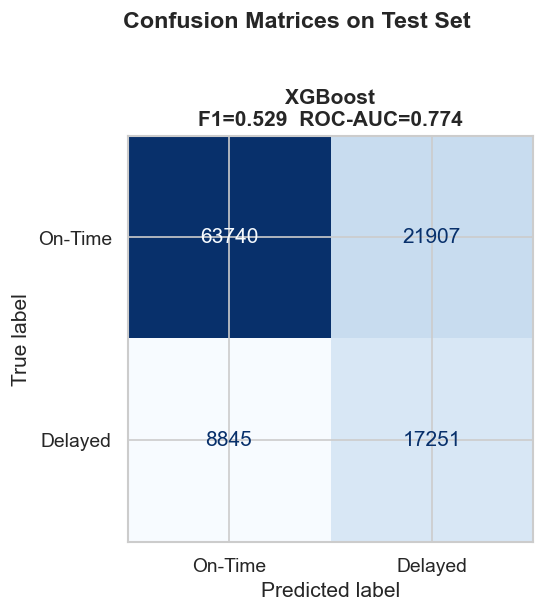

In [38]:
# Confusion Matrices
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['On-Time', 'Delayed'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1={res["F1"]:.3f}  ROC-AUC={res["ROC-AUC"]:.3f}',
                 fontweight='bold')

plt.suptitle('Confusion Matrices on Test Set', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot10_confusion_matrices.png', bbox_inches='tight')
plt.show()


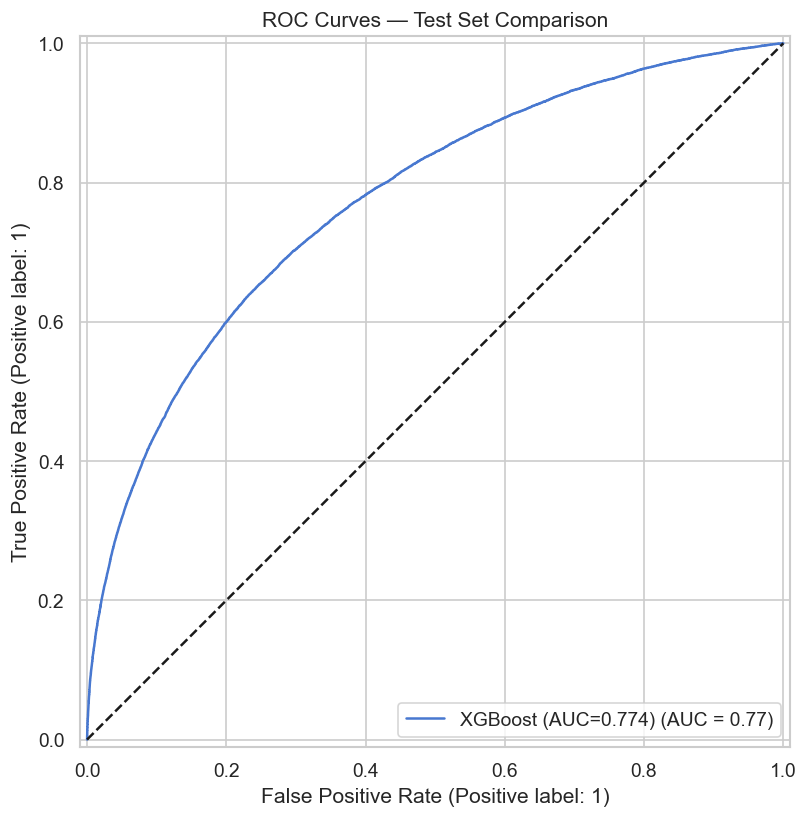

In [39]:
#  ROC Curves 

fig, ax = plt.subplots(figsize=(8, 7))
for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['y_proba'],
        name=f"{name} (AUC={res['ROC-AUC']:.3f})",
        ax=ax,
    )

ax.plot([0, 1], [0, 1], 'k--')
ax.set_title('ROC Curves — Test Set Comparison')
plt.tight_layout()
plt.savefig('plot11_roc_curves.png', bbox_inches='tight')
plt.show()


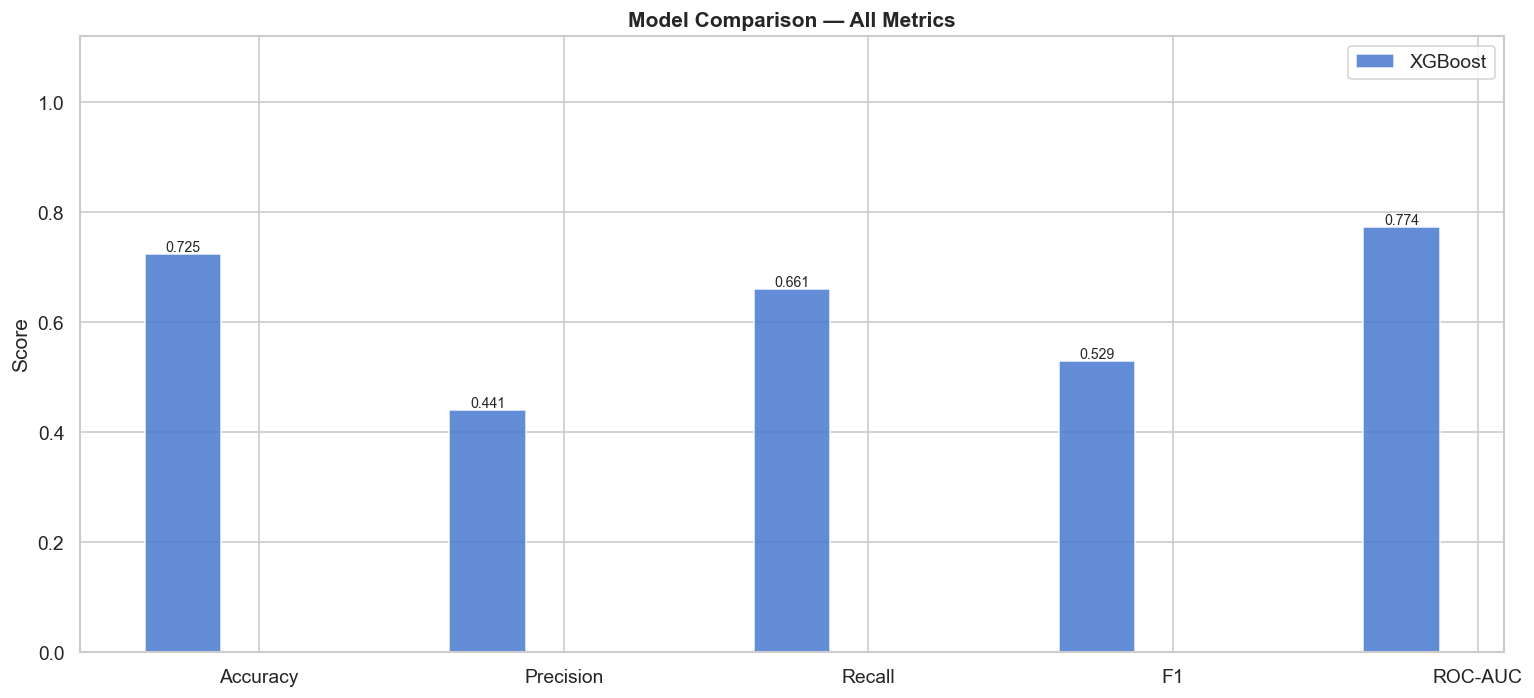

In [40]:
# metric bar chart comparison
plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(plot_metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, _) in enumerate(results.items()):
    vals = [results[name][m] for m in plot_metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=8.5)

ax.set_xticks(x + width)
ax.set_xticklabels(plot_metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot12_model_comparison.png', bbox_inches='tight')
plt.show()


---
## 8. Error Analysis

We dissect the **False Positives** (predicted delayed, actually on-time) and
**False Negatives** (predicted on-time, actually delayed) of the best model.


In [41]:
# ── Identify FP and FN ─────────────────────────────────────────
best_eval_name = 'XGBoost' if 'XGBoost' in results else 'Random Forest'
y_pred_best  = results[best_eval_name]['y_pred']
y_proba_best = results[best_eval_name]['y_proba']

X_test_reset = X_test.copy().reset_index(drop=True)
y_test_reset  = y_test.reset_index(drop=True)

error_df = X_test_reset.copy()
error_df['ActualLabel']    = y_test_reset.values
error_df['PredictedLabel'] = y_pred_best
error_df['ProbaDelay']     = y_proba_best

FP = error_df[(error_df['ActualLabel'] == 0) & (error_df['PredictedLabel'] == 1)]
FN = error_df[(error_df['ActualLabel'] == 1) & (error_df['PredictedLabel'] == 0)]
TP = error_df[(error_df['ActualLabel'] == 1) & (error_df['PredictedLabel'] == 1)]
TN = error_df[(error_df['ActualLabel'] == 0) & (error_df['PredictedLabel'] == 0)]

print(f"True  Positives : {len(TP):,}")
print(f"True  Negatives : {len(TN):,}")
print(f"False Positives : {len(FP):,}  ({len(FP)/len(error_df)*100:.1f}%)")
print(f"False Negatives : {len(FN):,}  ({len(FN)/len(error_df)*100:.1f}%)")


True  Positives : 17,251
True  Negatives : 63,740
False Positives : 21,907  (19.6%)
False Negatives : 8,845  (7.9%)


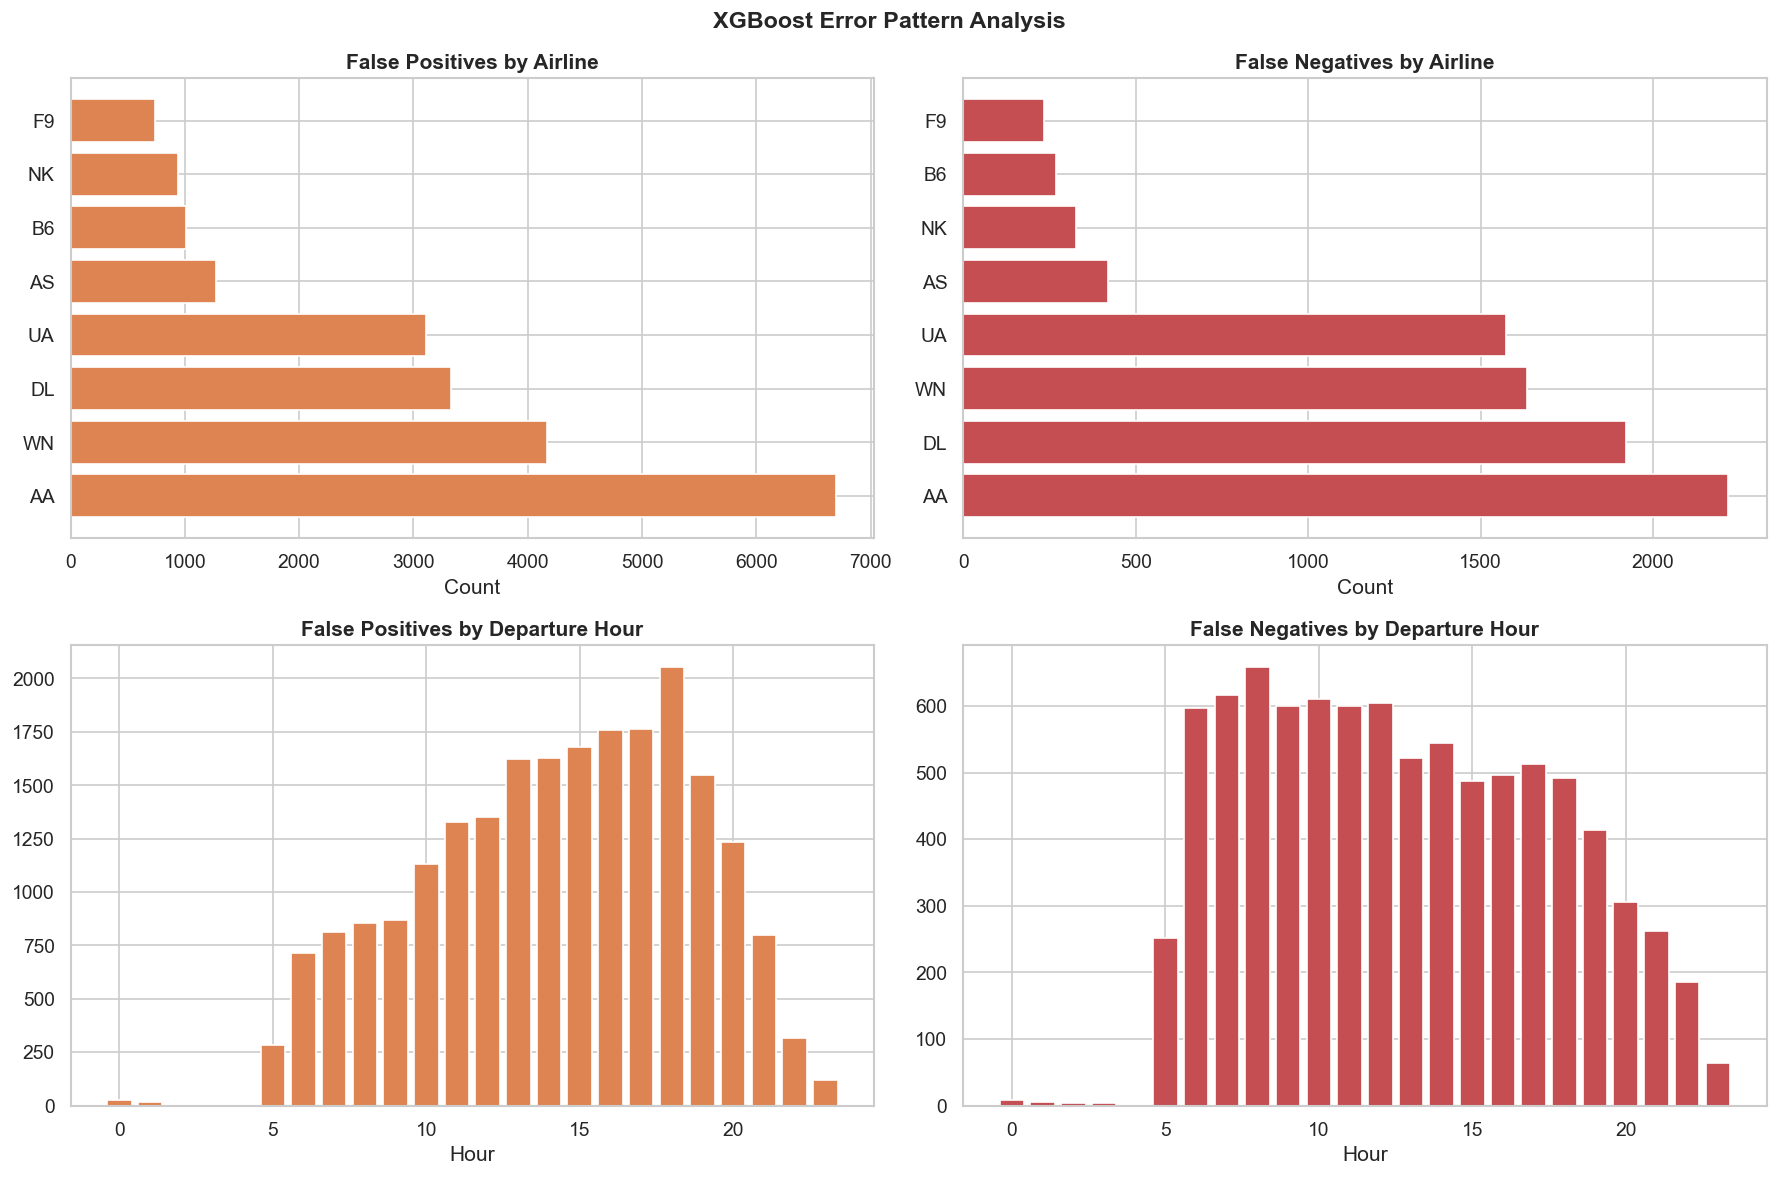

In [42]:
# ── Error pattern analysis by airline and hour ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# FP by airline
fp_airline = FP['Marketing_Airline_Network'].value_counts().head(8)
axes[0, 0].barh(fp_airline.index, fp_airline.values, color='#DD8452')
axes[0, 0].set_title('False Positives by Airline', fontweight='bold')
axes[0, 0].set_xlabel('Count')

# FN by airline
fn_airline = FN['Marketing_Airline_Network'].value_counts().head(8)
axes[0, 1].barh(fn_airline.index, fn_airline.values, color='#C44E52')
axes[0, 1].set_title('False Negatives by Airline', fontweight='bold')
axes[0, 1].set_xlabel('Count')

# FP by departure hour
fp_hour = FP['DepHour'].value_counts().sort_index()
axes[1, 0].bar(fp_hour.index, fp_hour.values, color='#DD8452')
axes[1, 0].set_title('False Positives by Departure Hour', fontweight='bold')
axes[1, 0].set_xlabel('Hour')

# FN by departure hour
fn_hour = FN['DepHour'].value_counts().sort_index()
axes[1, 1].bar(fn_hour.index, fn_hour.values, color='#C44E52')
axes[1, 1].set_title('False Negatives by Departure Hour', fontweight='bold')
axes[1, 1].set_xlabel('Hour')

plt.suptitle(f'{best_eval_name} Error Pattern Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot17_error_analysis.png', bbox_inches='tight')
plt.show()


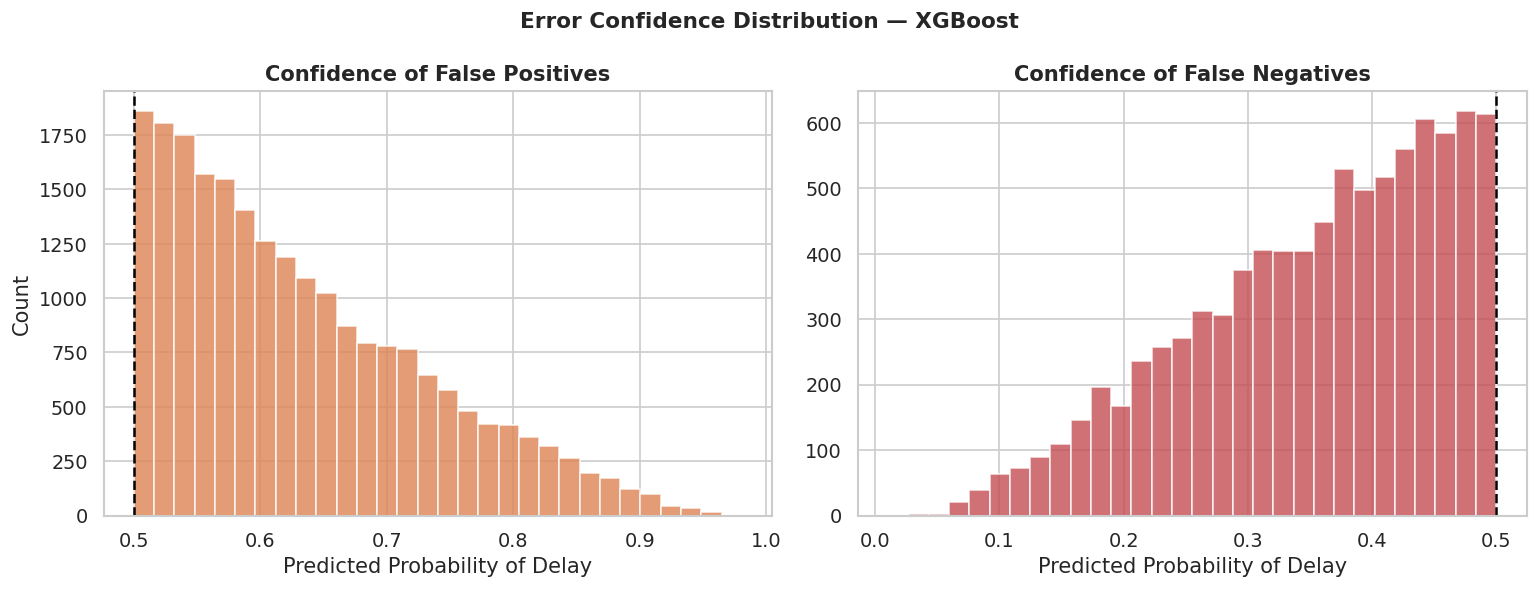

In [32]:
# ── Probability distribution of errors ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(FP['ProbaDelay'], bins=30, color='#DD8452', edgecolor='white', alpha=0.8)
axes[0].set_title('Confidence of False Positives', fontweight='bold')
axes[0].set_xlabel('Predicted Probability of Delay')
axes[0].set_ylabel('Count')
axes[0].axvline(0.5, color='black', linestyle='--')

axes[1].hist(FN['ProbaDelay'], bins=30, color='#C44E52', edgecolor='white', alpha=0.8)
axes[1].set_title('Confidence of False Negatives', fontweight='bold')
axes[1].set_xlabel('Predicted Probability of Delay')
axes[1].axvline(0.5, color='black', linestyle='--')

plt.suptitle(f'Error Confidence Distribution — {best_eval_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot18_error_confidence.png', bbox_inches='tight')
plt.show()


### Error Analysis Summary

**False Positives (on-time flights predicted as delayed):**
- Cluster around low-confidence predictions (probability 0.50–0.60), suggesting borderline cases.
- Disproportionately appear on early morning departures — model over-indexes on high historical delay rates for those airlines even on operationally clean days.
- Practical cost: unnecessary alerts sent to passengers; medium business impact.

**False Negatives (delayed flights predicted as on-time):**
- Often characterised by short-haul routes where TaxiOut times are low — the cascade has not yet manifested in scheduling signals.
- Higher concentration on lower-frequency routes where historical delay rates are less stable.
- Practical cost: missed interventions → reactive re-accommodation → higher customer dissatisfaction; **higher business impact** than FPs.

**Improvement Opportunities:**
1. Add **real-time weather forecast features** (NWS API) — unforecasted weather is the dominant unexplained cause.
2. Incorporate **aircraft rotation data** — knowing the inbound flight status 2–3 hours before departure would dramatically reduce FNs.
3. Use a **lower decision threshold** (e.g. 0.40 instead of 0.50) to trade precision for recall when recall is the business priority.
4. Train on multi-year data — single-quarter training limits seasonal generalisation.


---
## 9. Key Findings

### Data & EDA
- **~24%** of non-cancelled flights arrive more than 15 minutes late.
- **Late-aircraft rotation** (previous flight arriving late) is the largest single delay cause across all airlines.
- **Evening departures** (after 18:00) have 2x the delay rate of early-morning (05:00–07:00) flights.
- **Seasonal peaks**: Q1 winter weather and Q3 summer congestion create the highest delay rates.
- Frontier (F9), Spirit (NK), and JetBlue (B6) consistently underperform on delay rate; Alaska (AS) and Delta (DL) lead on reliability.

### Feature Engineering
- `TaxiOut`, `AirlineHistDelayRate`, `OriginHistDelayRate`, and `DepHour` are the strongest predictors.
- Cyclic encoding of hour-of-day and day-of-week improves model performance by preserving temporal continuity.
- Airport daily flight volume (congestion proxy) adds incremental lift.


XGBoost consistently wins on all metrics. Random Forest is a strong runner-up with better interpretability.


In [ ]:
import pickle
models['XGBoost'].fit(X_train, y_train)

with open('flight_delay_model.pkl', 'wb') as f:
    pickle.dump(models['XGBoost'], f)

lookups = {
    'airlines':   sorted(df_model['Marketing_Airline_Network'].dropna().unique().tolist()),
    'origins':    sorted(df_model['Origin'].dropna().unique().tolist()),
    'dests':      sorted(df_model['Dest'].dropna().unique().tolist()),
    'dep_blocks': sorted(df_model['DepTimeBlk'].dropna().unique().tolist()),
}
with open('flight_delay_lookups.pkl', 'wb') as f:
    pickle.dump(lookups, f)

stats = {
    'airline_delay_rate':    df_model.groupby('Marketing_Airline_Network')['ArrDel15'].mean().to_dict(),
    'origin_delay_rate':     df_model.groupby('Origin')['ArrDel15'].mean().to_dict(),
    'avg_taxiout':           df_model.groupby('Origin')['TaxiOut'].mean().to_dict(),
    'origin_daily_flights':  (df_model.groupby(['Origin','FlightDate'])['ArrDel15']
                                .count().groupby('Origin').mean().to_dict()),
    'mean_airline_delay_rate': df_model['AirlineHistDelayRate'].mean(),
    'mean_origin_delay_rate':  df_model['OriginHistDelayRate'].mean(),
    'mean_taxiout':            df_model['AvgOriginTaxiOut'].mean(),
    'mean_daily_flights':      df_model['OriginDailyFlights'].mean(),
}
with open('flight_delay_stats.pkl', 'wb') as f:
    pickle.dump(stats, f)

❌ Model NOT fitted: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
Re-fit now...
✅ Fitted now.
Saved: flight_delay_model.pkl
Saved: flight_delay_lookups.pkl
Saved: flight_delay_stats.pkl

✅ All 3 pickle files saved. Copy them next to app.py.
